In [110]:
# Jaxlib
import jax
from jax import lax
from jax import random as jrnd
from jax import numpy as jnp
from jax import tree_util as jtu
jax.config.update('jax_enable_x64', True)

# Others
from matplotlib import pyplot as plt

# This
from numerics import *
from seismic import *

In [111]:
site = Site(0., 0., 760., 0.5, 2.9, 1.)
mfd1 = MFD(4., .8, 4., 8.)
mfd2 = MFD(4., 1., 4., 8.)
mfd3 = MFD(5., 1.2, 4., 5.)
fault1 = Fault(0., 20., 3.0, 0.1, 40., 80., 90., 2.5, 0., mfd1)
fault2 = Fault(0., 25., 0.5, 0.2, 80., 80., 30., 0.5, 1., mfd2)
fault3 = Fault(22., 12.1, 3.9, 1.2, 130., 40., 22., 3., 1., mfd3)
fault_tree = make_fault_tree(fault1)
scn = Scenario(site, fault_tree)

In [121]:
import jax
from jax import lax
from jax import numpy as jnp

import polars as pl
from importlib.resources import files

from seismic.gm_utils import *

gmc = pl.read_csv(files("seismic") / "BSSA14_coeffs.csv")

gmc[-2, 'T'] = -1.
gmc[-1, 'T'] = -2.
gmc = gmc.with_columns([pl.col("T").cast(pl.Float64)])
gmc = gmc.sort('T')
gmc_col = gmc.columns
for i,col in enumerate(gmc_col):
    print(i, col)
gmc = gmc.cast(pl.Float64).to_jax().T

0 T
1 e0
2 e1
3 e2
4 e3
5 e4
6 e5
7 e6
8 Mh
9 c1
10 c2
11 c3
12 Mref
13 Rref
14 h
15 Dc3CaTw
16 Dc3CnTr
17 Dc3ItJp
18 c
19 Vc
20 Vref
21 f1
22 f3
23 f4
24 f5
25 f6
26 f7
27 R1
28 R2
29 dPhiR
30 dPhiV
31 v1
32 v2
33 phi1
34 phi2
35 tau1
36 tau2


In [189]:
import jax
from jax import lax
from jax import numpy as jnp
from jax import random as jrnd
from jax.typing import ArrayLike

import polars as pl 
from importlib.resources import files

from seismic.gm_utils import *

gmc = pl.read_csv(files("seismic") / "CY14_coeffs.csv")
gmc[-2, 'T'] = -1.
gmc[-1, 'T'] = -2.
gmc = gmc.with_columns([pl.col("T").cast(pl.Float64)])
gmc = gmc.sort('T')
gmc_col = gmc.columns
gmc_df = gmc
gmc = gmc.cast(pl.Float64).to_jax().T
T_CY = gmc[0]
empty_all = jnp.zeros_like(T_CY)

print(T_CY)


[-2.    -1.     0.01   0.02   0.03   0.04   0.05   0.075  0.1    0.15
  0.2    0.25   0.3    0.4    0.5    0.75   1.     1.5    2.     3.
  4.     5.     7.5   10.   ]


In [190]:
# c_RB, c_n, c_M, c_HM
c_other_all = gmc[jnp.array([4, 12, 13, 16])]

# c1, c1a-d
c1_all = gmc[7:12]
c_max_shape = c1_all.shape[0]
# c2, c3
c2_all, c3_all, c5_all = gmc[jnp.array([1, 14, 15])]
c2_all = jnp.pad(c2_all[None], ((0, c_max_shape - 1), (0, 0)))
c3_all = jnp.pad(c3_all[None], ((0, c_max_shape - 1), (0, 0)))
c5_all = jnp.pad(c5_all[None], ((0, c_max_shape - 1), (0, 0)))
# c4, c4a
c4_all = gmc[2:4]
c4_all = jnp.pad(c4_all, ((0, c_max_shape - c4_all.shape[0]), (0, 0)))
c6_all = gmc[17]
c6_all = jnp.pad(c6_all[None], ((0, c_max_shape - 1), (0, 0)))
# c7, c7b
c7_all = gmc[18:20]
c7_all = jnp.insert(c7_all, 1, empty_all, axis = 0)
c7_all = jnp.pad(c7_all, ((0, c_max_shape - c7_all.shape[0]), (0, 0)))
# c8, c8a, c8b
c8_all = gmc[jnp.array([5, 6, 20])]
c8_all = jnp.pad(c8_all, ((0, c_max_shape - c8_all.shape[0]), (0, 0)))
# c9, c9a
c9_all = gmc[21:24]
c9_all = jnp.pad(c9_all, ((0, c_max_shape - c9_all.shape[0]), (0, 0)))
# c11, c11b
c11_all = gmc[24:26]
c11_all = jnp.insert(c11_all, 1, empty_all, axis = 0)
c11_all = jnp.pad(c11_all, ((0, c_max_shape - c11_all.shape[0]), (0, 0)))
c_all = jnp.stack([jnp.zeros_like(c1_all), c1_all, c2_all, c3_all, c4_all, c5_all, c6_all, c7_all, c8_all, c9_all, c11_all])

# c_gamma, phi, tau, sigma
c_gamma_all = jnp.insert(gmc[26:29], 0, empty_all, axis = 0)
c_phi_all = jnp.insert(gmc[29:35], 0, empty_all, axis = 0)
c_tau_all = jnp.insert(gmc[35:37], 0, empty_all, axis = 0)
c_sigma_all = jnp.insert(gmc[37:40], 0, empty_all, axis = 0)
# Unused...
c_sigma2_JP_all, c_gamma_JP_IT_all, c_gamma_WN_all = gmc[40:43]
c_phi1_JP_all, c_phi5_JP_all, c_phi6_JP_all = gmc[43:]

A = 571. ** 4
B = 1360. ** 4 + A

In [200]:
def slice_coeffs(T):
    # T_idx = jnp.searchsorted(T_CY, T) - 1
    # T_slice = lax.dynamic_slice_in_dim(T_CY, T_idx, 2, axis = -1)
    # c = lax.dynamic_slice_in_dim(c_all, T_idx, 2, axis = -1)
    # c_gamma = lax.dynamic_slice_in_dim(c_gamma_all, T_idx, 2, axis = -1)
    # c_phi = lax.dynamic_slice_in_dim(c_phi_all, T_idx, 2, axis = -1)
    # c_tau = lax.dynamic_slice_in_dim(c_tau_all, T_idx, 2, axis = -1)
    # c_sigma = lax.dynamic_slice_in_dim(c_sigma_all, T_idx, 2, axis = -1)
    # c_other = lax.dynamic_slice_in_dim(c_other_all, T_idx, 2, axis = -1)
    
    #return (T_slice, c, c_gamma, c_phi, c_tau, c_sigma, c_other)
    return (T_CY, c_all, c_gamma_all, c_phi_all, c_tau_all, c_sigma_all, c_other_all)


def f_SA_ref(Mw, dip, z_tor, SOF_flag,  R_jb, R_rup, R_x, 
             c, c_other, c_gamma):
    c_RB, c_n, c_M, c_HM = c_other
    dip_rad = jnp.deg2rad(dip)

    r1 = c[1, 0] + c[2, 0] * (Mw - 6.) + ((c[2, 0] - c[3, 0]) / c_n) * jnp.log(1 + jnp.exp(c_n * (c_M - Mw)))
    r2 = c[4, 0] * jnp.log(R_rup + c[5, 0] * jnp.cosh(c[6, 0] * jnp.maximum(Mw - c_HM, 0.)))
    gamma = c_gamma[1] + c_gamma[2] / jnp.cosh(jnp.maximum(Mw - c_gamma[3], 0.))
    r3 = (c[4, 1] - c[4, 0]) * jnp.log(jnp.sqrt(R_rup ** 2 + c_RB ** 2)) + R_rup * gamma

    cosh_Mw = jnp.cosh(2 * jnp.maximum(Mw - 4.5, 0.))
    cos_dip = jnp.cos(dip_rad)

    # Calculate Mw_z_tor (separate fn in nshmp-haz)
    # REVIEW Mw_Z_TOP
    is_rev = SOF_flag == -1.
    Mw_z_tor_rev = lambda Mw: jnp.clip(2.704 - 1.226 *(Mw - 5.849) , min = 0., max = 2.704)
    Mw_z_tor_else = lambda Mw: jnp.clip(2.673 - 1.136 *(Mw - 4.970) , min = 0., max = 2.673)
    Mw_z_tor = lax.cond(is_rev, Mw_z_tor_rev, Mw_z_tor_else, Mw)

    dz_tor = z_tor - Mw_z_tor

    r4 = ((c[7, 0] + c[7, 2] / cosh_Mw) * dz_tor + (c[11, 0] + c[11, 2] / cosh_Mw) * cos_dip ** 2)
    # Multiply by abs value of flag to account for strike slip where additional factor is zero
    c_style1, c_style2 = lax.select(is_rev, c[1, 1:4:2], c[1, 2:5:2]) * jnp.abs(SOF_flag)
    r4 = r4 + (c_style1 + c_style2 / cosh_Mw)
    
    r5_cond = R_x >= 0.
    r5_true = lambda R_x, R_jb, z_tor: c[9, 0] * jnp.cos(dip_rad) * \
                    (c[9, 1] + (1 - c[9, 1]) * jnp.tanh(R_x / c[9, 2])) * \
                    (1 - jnp.sqrt(R_jb ** 2 + z_tor ** 2) / (R_rup + 1.))
    r5_false = lambda R_x, R_jb, z_tor: jnp.zeros_like(c_n)
    r5 = lax.cond(r5_cond, r5_true, r5_false, R_x, R_jb, z_tor)
    
    return jnp.exp(r1 + r2 + r3 + r4 + r5)

def f_lnSA(vs30, z1p0, SA_ref, soil_nonlin,
           c_phi):
    soil_lin = c_phi[1] * jnp.minimum(jnp.log(vs30 / 1130.), 0.)
    soil_nonlin_mod = soil_nonlin * jnp.log((SA_ref + c_phi[4]) / c_phi[4])

    # Calculate delta z1p0 (separate fn in nshmp-haz)
    z1p0_ref = jnp.exp(-7.15 / 4 * jnp.log((vs30 ** 4 + A) / B))
    dz1p0 = (z1p0 * 1000) - z1p0_ref

    rk_depth = c_phi[5] * (1. - jnp.exp(-dz1p0 / c_phi[6]))

    return jnp.log(SA_ref) + soil_lin + soil_nonlin_mod + rk_depth

def f_std(Mw, vs30inf_flag, SA_ref, soil_nonlin,
          c_phi, c_tau, c_sigma):
    nonlin_0 = soil_nonlin * SA_ref / (SA_ref + c_phi[4])
    nonlin_0sq = (1 + nonlin_0) ** 2
    Mw_thresh = jnp.clip(Mw - 5., min = 0, max = 1.5)
    tau = c_tau[1] + (c_tau[2] - c_tau[1]) / 1.5 * Mw_thresh

    sig_nonlin_0 = c_sigma[1] + (c_sigma[2] - c_sigma[1]) / 1.5 * Mw_thresh
    vs_term = jnp.where(vs30inf_flag == 1., c_sigma[3], 0.7)
    sig_nonlin_0 = sig_nonlin_0 * jnp.sqrt(vs_term + nonlin_0sq)

    return (tau ** 2 * nonlin_0sq + sig_nonlin_0 ** 2)

def f_CY14(Mw:float, T:float, site:Site, fault:Fault, R:jax.Array,):
    T_slice, c, c_gamma, c_phi, c_tau, c_other, c_sigma = slice_coeffs(T)

    SOF_flag = fault.calc_SOF_flag()
    R_jb, R_rup, R_epi, R_hyp, R_x = R
    SA_ref = f_SA_ref(Mw, fault.dip, fault.z_tor, SOF_flag, R_jb, R_rup, R_x,
                      c, c_other, c_gamma)

    # Calculate nonlinear attenuation effect (separate fn in nshmp-haz)
    soil_nonlin1 = jnp.exp(c_phi[3] * (jnp.minimum(site.vs30, 1130.) - 360.))
    soil_nonlin2 = jnp.exp(c_phi[3] * (1130. - 360.))
    soil_nonlin = c_phi[2] * (soil_nonlin1 - soil_nonlin2)

    lnSA = f_lnSA(site.vs30, site.z1p0, SA_ref, soil_nonlin,
                  c_phi)
    std = f_std(Mw, site.vs30inf_flag, SA_ref, soil_nonlin,
                c_phi, c_tau, c_sigma)

    lnSA = jnp.interp(T, T_slice, lnSA)
    std = jnp.interp(T, T_slice, std)

    return lnSA, std

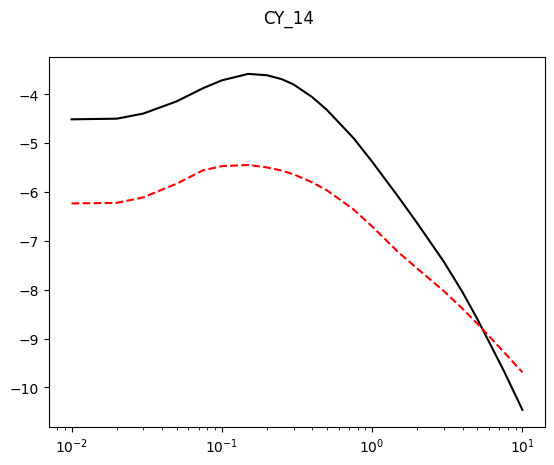

In [201]:
import requests

def test_model(Mw, fault:Fault, site:Site, name, model, apitest:bool = True):
    R = calc_R(site, fault)
    R_jb, R_rup, R_epi, R_hyp, R_x = R

    # API
    if apitest:
        url_base = 'https://earthquake.usgs.gov/ws/nshmp/gmm/spectra?'
        url_inputs = (name, Mw, R_jb, R_rup, R_x, fault.dip, fault.width, 
                    fault.z_tor, fault.z_hyp, fault.rake, 
                    site.vs30, site.z1p0, site.z2p5)
        url_addn = 'gmm=%s&Mw=%s&rJB=%s&rRup=%s&rX=%s&dip=%s&width=%s&z_tor=%s&z_hyp=%s&rake=%s&vs30=%s&z1p0=%s&z2p5=%s'%url_inputs
        json = requests.get(url_base + url_addn).json()
        api_T = json['response']['means']['data'][0]['data']['sa']['xs']
        api_PGA, api_PGV = [json['response']['means']['data'][0]['data'][key] for key in ['pga', 'pgv']]
        if api_PGV is None:
            api_PGV = jnp.nan
        api_SA = json['response']['means']['data'][0]['data']['sa']['ys']
        api_T, api_SA= [jnp.array(_) for _ in [api_T, api_SA]]
        #api_T = jnp.append(api_T, jnp.array([-1, -2]))
        #api_SA = jnp.append(api_SA, jnp.array([api_PGA, api_PGV]))
        api_lnSA = jnp.log(api_SA)
        my_lnSA, my_sigma = jax.vmap(model, in_axes = (None, 0, None, None, None))(Mw, api_T, site, fault, R)
        #my_T, my_lnSA, my_sigma = model(Mw, api_T, site, fault, R)
        plt.plot(api_T, api_lnSA, c = 'k')
        plt.plot(api_T, my_lnSA, c = 'r', ls = '--')
    else:
        unif_T = [0.01, 0.02, 0.03, 0.05, 0.075, 0.1, 0.15, 0.2, 0.25, 0.3, 0.4, 0.5, 0.75, 1., 1.5, 2., 3., 4., 5., 7.5, 10.]
        unif_T = jnp.array(unif_T)
        my_lnSA, my_sigma = model(Mw, unif_T, site, fault, R)
        #my_lnSA, my_sigma = jax.vmap(model, in_axes = (None, 0, None, None, None))(Mw, unif_T, site, fault, R)
        plt.plot(unif_T, my_lnSA, c = 'r', ls = '--')
    plt.xscale('log')
    plt.suptitle(name)
    plt.show()

for m,n in [(f_CY14, 'CY_14')]:#zip([f_ASK14, f_Idriss14, f_BSSA14, f_CB14, f_CY14], 
           #    ['ASK_14', 'IDRISS_14', 'BSSA_14', 'CB_14', 'CY_14']):
    test_model(4.9, fault3, site, n, m, apitest = True)